In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
vs = pd.read_csv("Voltage Source.txt", sep="\t")
vr = pd.read_csv("R1.txt", sep="\t")
vl = pd.read_csv("L1.txt", sep="\t")
vc = pd.read_csv("C1.txt", sep="\t")

In [4]:
vs.columns = ["time", "vs"]
vr.columns = ["time", "vR"]
vl.columns = ["time", "vL"]
vc.columns = ["time", "vC"]

In [5]:
df = vs.merge(vr, on="time")
df = df.merge(vl, on="time")
df = df.merge(vc, on="time")

In [6]:
df.head()


,time,vs,vR,vL,vC
0,0.000000e+00,-0.000000,0.000000e+00,0.000000,0.000000e+00
1,1.000000e-09,-0.000005,1.364242e-12,0.000005,1.616965e-19
2,1.024000e-09,-0.000005,9.094947e-13,0.000005,1.656726e-19
3,1.072000e-09,-0.000006,1.364242e-12,0.000006,1.738199e-19
4,1.168000e-09,-0.000006,1.364242e-12,0.000006,1.913395e-19


In [7]:
df["vs_fixed"] = -df["vs"]
df["vSUM"] = df["vR"] + df["vL"] + df["vC"]
df["abs_error"] = np.abs(df["vs_fixed"] + df["vSUM"])

In [8]:
df["abs_error"] = np.abs(df["vs_fixed"] + df["vSUM"])

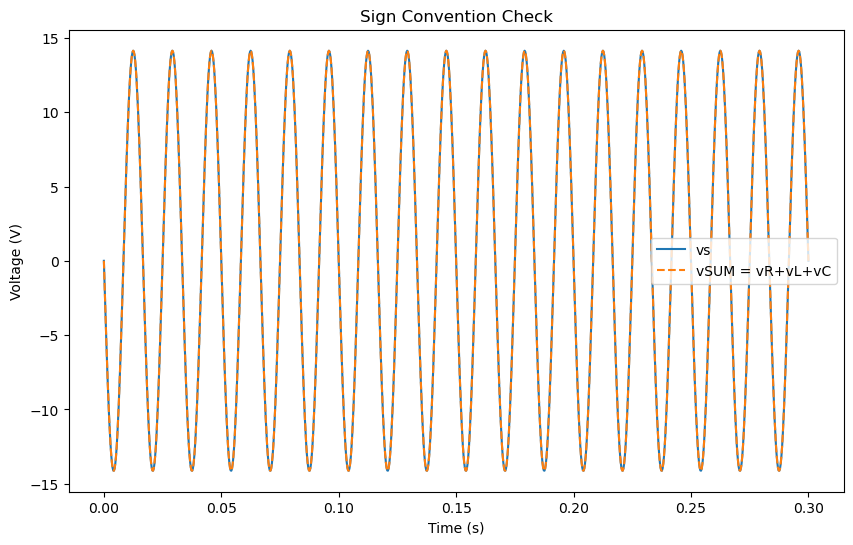

In [38]:
plt.figure(figsize=(10,6))
plt.plot(df["time"], df["vs"], label="vs")
#plt.plot(df["time"], -df["vs"], label="-vs imported")
plt.plot(df["time"], df["vSUM"], "--", label="vSUM = vR+vL+vC")
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Sign Convention Check")
plt.show()

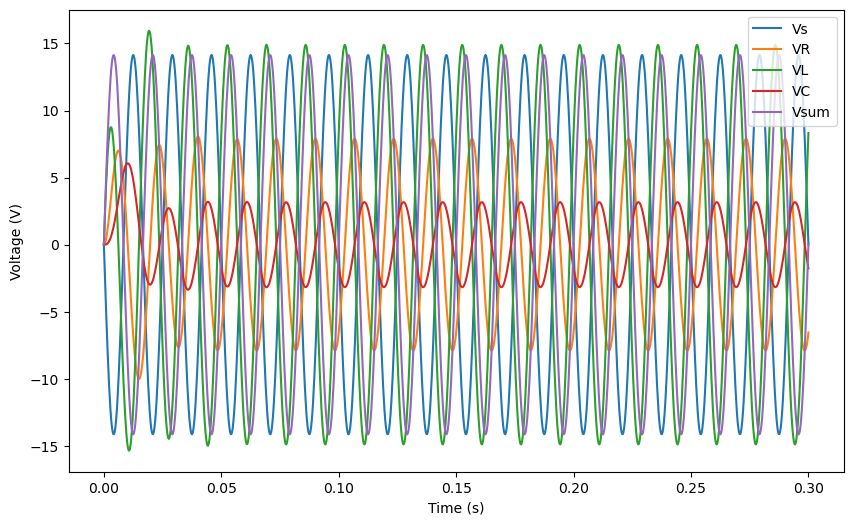

In [10]:
plt.figure(figsize=(10,6))

plt.plot(df["time"], df["vs"], label="Vs")
plt.plot(df["time"], df["vR"], label="VR")
plt.plot(df["time"], df["vL"], label="VL")
plt.plot(df["time"], df["vC"], label="VC")
plt.plot(df["time"], df["vSUM"], label="Vsum")

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")

plt.show()

In [11]:
df["abs_error"] = np.abs(df["vs_fixed"] - df["vSUM"])

threshold = 1e-3  # 1 mV threshold

df["percent_diff"] = np.where(
    np.abs(df["vs_fixed"]) > threshold,
    df["abs_error"] / np.abs(df["vs_fixed"]) * 100,
    np.nan
)

In [12]:
df["abs_error"].max()

np.float64(9.00000000214618e-06)

In [13]:
df["abs_error"].describe()

count    1.068000e+03
mean     2.147503e-06
std      2.175737e-06
min      0.000000e+00
25%      2.000000e-07
50%      1.150000e-06
75%      4.000000e-06
max      9.000000e-06
Name: abs_error, dtype: float64

In [14]:
df["percent_diff"]

0                NaN
1                NaN
2                NaN
3                NaN
4                NaN
            ...     
1063    3.867522e-06
1064    1.203759e-14
1065    0.000000e+00
1066    1.642686e-05
1067             NaN
Name: percent_diff, Length: 1068, dtype: float64

In [15]:
df["percent_diff_exact"] = np.abs(df["vs"] - df["vSUM"]) / np.abs(df["vs"]) * 100

In [16]:
df["abs_error"] = np.abs(df["vs"] - df["vSUM"])

threshold = 1e-3

df["percent_diff"] = np.where(
    np.abs(df["vs"]) > threshold,
    df["abs_error"] / np.abs(df["vs"]) * 100,
    np.nan
)

In [17]:
df["abs_error"]

0       0.000000e+00
1       1.066131e-05
2       1.091718e-05
3       1.142892e-05
4       1.245241e-05
            ...     
1063    1.034254e+01
1064    7.378374e+00
1065    4.324294e+00
1066    1.217518e+00
1067    9.999999e-07
Name: abs_error, Length: 1068, dtype: float64

In [18]:
df["vSUM"] = -(df["vR"] + df["vL"] + df["vC"])
df["abs_error"] = np.abs(df["vs_fixed"] + df["vSUM"])

In [19]:
df["abs_error"].max()

np.float64(9.00000000214618e-06)

In [20]:
df["abs_error"].idxmin()

0

In [22]:
df["abs_error"].idxmax()

566

In [21]:
df.corr()

,time,vs,vR,vL,vC,vs_fixed,vSUM,abs_error,percent_diff,percent_diff_exact
time,1.000000,0.042656,-0.016043,-0.017698,-0.065083,-0.042656,0.042656,0.069710,-0.000418,0.053075
vs,0.042656,1.000000,-0.568340,-0.824798,0.778941,-1.000000,1.000000,0.009273,-0.019032,-0.000054
vR,-0.016043,-0.568340,1.000000,0.007181,0.002266,0.568340,-0.568340,-0.003348,0.006928,-0.036176
vL,-0.017698,-0.824798,0.007181,1.000000,-0.968284,0.824798,-0.824798,-0.007010,0.025888,0.025142
vC,-0.065083,0.778941,0.002266,-0.968284,1.000000,-0.778941,0.778941,-0.000272,-0.051235,-0.025688
vs_fixed,-0.042656,-1.000000,0.568340,0.824798,-0.778941,1.000000,-1.000000,-0.009273,0.019032,0.000054
vSUM,0.042656,1.000000,-0.568340,-0.824798,0.778941,-1.000000,1.000000,0.009273,-0.019032,-0.000054
abs_error,0.069710,0.009273,-0.003348,-0.007010,-0.000272,-0.009273,0.009273,1.000000,-0.049095,-0.016189
percent_diff,-0.000418,-0.019032,0.006928,0.025888,-0.051235,0.019032,-0.019032,-0.049095,1.000000,1.000000
percent_diff_exact,0.053075,-0.000054,-0.036176,0.025142,-0.025688,0.000054,-0.000054,-0.016189,1.000000,1.000000


In [23]:
#df.sample(5)
df.info()
#df.columns
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   time                1068 non-null   float64
 1   vs                  1068 non-null   float64
 2   vR                  1068 non-null   float64
 3   vL                  1068 non-null   float64
 4   vC                  1068 non-null   float64
 5   vs_fixed            1068 non-null   float64
 6   vSUM                1068 non-null   float64
 7   abs_error           1068 non-null   float64
 8   percent_diff        1053 non-null   float64
 9   percent_diff_exact  1067 non-null   float64
dtypes: float64(10)
memory usage: 83.6 KB


(1068, 10)

In [24]:
df.sort_values("abs_error", ascending=False).head()

,time,vs,vR,vL,vC,vs_fixed,vSUM,abs_error,percent_diff,percent_diff_exact
566,0.153694,-13.91644,3.181294,13.63652,-2.901365,13.91644,-13.916449,0.000009,200.000065,200.000065
879,0.245231,13.77680,-2.822819,-13.91443,2.960458,-13.77680,13.776791,0.000009,199.999935,199.999935
936,0.261897,13.77680,-2.822819,-13.91443,2.960458,-13.77680,13.776791,0.000009,199.999935,199.999935
651,0.178564,13.77680,-2.822819,-13.91443,2.960458,-13.77680,13.776791,0.000009,199.999935,199.999935
708,0.195231,13.77680,-2.822819,-13.91443,2.960458,-13.77680,13.776791,0.000009,199.999935,199.999935


In [25]:
df[df["time"] > 0.05]

,time,vs,vR,vL,vC,vs_fixed,vSUM,abs_error,percent_diff,percent_diff_exact
212,0.050179,-9.524047e-01,-6.244114,9.091677,-1.895158,9.524047e-01,-9.524050e-01,3.000000e-07,200.000031,2.000000e+02
213,0.050472,-2.501604e+00,-5.674767,10.336060,-2.159693,2.501604e+00,-2.501600e+00,4.000000e-06,199.999840,1.999998e+02
214,0.050765,-4.020319e+00,-5.036230,11.453970,-2.397419,4.020319e+00,-4.020321e+00,2.000000e-06,200.000050,2.000000e+02
215,0.051058,-5.490042e+00,-4.336315,12.431800,-2.605439,5.490042e+00,-5.490046e+00,4.000000e-06,200.000073,2.000001e+02
216,0.051351,-6.892863e+00,-3.583578,13.257660,-2.781218,6.892863e+00,-6.892864e+00,1.000000e-06,200.000015,2.000000e+02
...,...,...,...,...,...,...,...,...,...,...
1063,0.299007,5.171270e+00,-7.707987,3.223507,-0.686790,-5.171270e+00,5.171270e+00,2.000000e-07,199.999996,2.000000e+02
1064,0.299300,3.689187e+00,-7.472495,4.807023,-1.023715,-3.689187e+00,3.689187e+00,4.440892e-16,200.000000,2.000000e+02
1065,0.299593,2.162147e+00,-7.145943,6.331961,-1.348165,-2.162147e+00,2.162147e+00,0.000000e+00,200.000000,2.000000e+02
1066,0.299886,6.087591e-01,-6.732311,7.779739,-1.656187,-6.087591e-01,6.087590e-01,1.000000e-07,199.999984,2.000000e+02


In [111]:
df["time"].value_counts()

time
0.000000e+00    1
1.000000e-09    1
1.024000e-09    1
1.072000e-09    1
1.168000e-09    1
               ..
2.990069e-01    1
2.992998e-01    1
2.995928e-01    1
2.998858e-01    1
3.000000e-01    1
Name: count, Length: 1068, dtype: int64

In [26]:
df["abs_error"].describe()

df.loc[df["abs_error"].idxmax()]

df.sort_values("abs_error", ascending=False).head()

,time,vs,vR,vL,vC,vs_fixed,vSUM,abs_error,percent_diff,percent_diff_exact
566,0.153694,-13.91644,3.181294,13.63652,-2.901365,13.91644,-13.916449,0.000009,200.000065,200.000065
879,0.245231,13.77680,-2.822819,-13.91443,2.960458,-13.77680,13.776791,0.000009,199.999935,199.999935
936,0.261897,13.77680,-2.822819,-13.91443,2.960458,-13.77680,13.776791,0.000009,199.999935,199.999935
651,0.178564,13.77680,-2.822819,-13.91443,2.960458,-13.77680,13.776791,0.000009,199.999935,199.999935
708,0.195231,13.77680,-2.822819,-13.91443,2.960458,-13.77680,13.776791,0.000009,199.999935,199.999935


 # Analysis of theoretical, manually derived voltage, and LTSpice Voltage @ t = input

In [28]:
import numpy as np
import pandas as pd

# Circuit parameters
R = 2
L = 10e-3
C = 3.3e-3
f = 60
omega = 2 * np.pi * f

Vrms = 10
Vpeak = Vrms * np.sqrt(2)

deg = np.pi / 180

# Reactances
XL = omega * L
XC = 1 / (omega * C)

# Total impedance Z = R + j(XL - XC)
theta = np.arctan2((XL - XC), R)          # impedance angle in radians
Zmag = np.sqrt(R**2 + (XL - XC)**2)

# Current
Ipeak = Vpeak / Zmag

# Element voltage peak magnitudes
VR_peak = Ipeak * R
VL_peak = Ipeak * XL
VC_peak = Ipeak * XC

# Time-domain voltage equations
def vs_theory(t):
    return Vpeak * np.sin(omega * t)

def vR_theory(t):
    return VR_peak * np.sin(omega * t - theta)

def vL_theory(t):
    return VL_peak * np.sin(omega * t - theta + np.pi/2)

def vC_theory(t):
    return VC_peak * np.sin(omega * t - theta - np.pi/2)

def vSUM_theory(t):
    return vR_theory(t) + vL_theory(t) + vC_theory(t)

# Main comparison function
def compare_at_time(t_input, df=None):
    if not (0 <= t_input <= 0.3):
        raise ValueError("Time must be between 0 and 0.3 seconds.")

    result = {
        "time_requested": t_input,
        "vs_theory": vs_theory(t_input),
        "vR_theory": vR_theory(t_input),
        "vL_theory": vL_theory(t_input),
        "vC_theory": vC_theory(t_input),
        "vSUM_theory": vSUM_theory(t_input),
        "theory_abs_error": abs(vs_theory(t_input) - vSUM_theory(t_input)),
    }

    if df is not None:
        idx = (df["time"] - t_input).abs().idxmin()
        row = df.loc[idx]

        result.update({
            "time_ltspice": row["time"],
            "vs_ltspice": row["vs_fixed"],
            "vR_ltspice": row["vR"],
            "vL_ltspice": row["vL"],
            "vC_ltspice": row["vC"],
            "vSUM_ltspice": row["vSUM"],
            "ltspice_abs_error": abs(row["vs_fixed"] - row["vSUM"]),
            "vs_diff": abs(vs_theory(t_input) - row["vs_fixed"]),
            "vR_diff": abs(vR_theory(t_input) - row["vR"]),
            "vL_diff": abs(vL_theory(t_input) - row["vL"]),
            "vC_diff": abs(vC_theory(t_input) - row["vC"]),
            "vSUM_diff": abs(vSUM_theory(t_input) - row["vSUM"]),
        })

    return pd.Series(result)

In [29]:
t_user = float(input("Enter time in seconds between 0 and 0.3: "))
print(compare_at_time(t_user, df))

Enter time in seconds between 0 and 0.3:  0.2


time_requested       2.000000e-01
vs_theory           -4.156589e-14
vR_theory           -6.555371e+00
vL_theory            8.331877e+00
vC_theory           -1.776506e+00
vSUM_theory         -9.148238e-14
theory_abs_error     4.991649e-14
time_ltspice         1.998858e-01
vs_ltspice          -6.087590e-01
vR_ltspice          -6.732311e+00
vL_ltspice           7.779740e+00
vC_ltspice          -1.656187e+00
vSUM_ltspice         6.087580e-01
ltspice_abs_error    1.217517e+00
vs_diff              6.087590e-01
vR_diff              1.769400e-01
vL_diff              5.521370e-01
vC_diff              1.203190e-01
vSUM_diff            6.087580e-01
dtype: float64


In [34]:
times_to_check = [0.15, 0.159, 0.168, 0.172, 0.2]

comparison_table = pd.DataFrame([compare_at_time(t, df) for t in times_to_check])\
    .sort_values("time_requested", ascending=True)
comparison_table

,time_requested,vs_theory,vR_theory,vL_theory,vC_theory,vSUM_theory,theory_abs_error,time_ltspice,vs_ltspice,vR_ltspice,vL_ltspice,vC_ltspice,vSUM_ltspice,ltspice_abs_error,vs_diff,vR_diff,vL_diff,vC_diff,vSUM_diff
0,0.150,-1.316603e-13,-6.555371,8.331877,-1.776506,-7.371881e-14,5.794153e-14,0.149886,-0.608758,-6.732314,7.779742,-1.656186,0.608758,1.217516,0.608758,0.176943,0.552135,0.120320,0.608758
1,0.159,-3.517006e+00,5.250163,-11.143073,2.375904,-3.517006e+00,5.240253e-14,0.158968,-3.349947,5.317112,-11.010440,2.343381,3.349947,6.699894,0.167059,0.066949,0.132633,0.032523,6.866953
2,0.168,6.813026e+00,-3.615069,13.254109,-2.826014,6.813026e+00,4.352074e-14,0.168017,6.892550,-3.567728,13.288260,-2.827984,-6.892548,13.785098,0.079524,0.047341,0.034151,0.001970,13.705574
3,0.172,1.279619e+01,6.790656,7.633030,-1.627499,1.279619e+01,4.796163e-14,0.172119,12.511780,6.953753,7.059498,-1.501468,-12.511783,25.023563,0.284407,0.163097,0.573532,0.126031,25.307970
4,0.200,-4.156589e-14,-6.555371,8.331877,-1.776506,-9.148238e-14,4.991649e-14,0.199886,-0.608759,-6.732311,7.779740,-1.656187,0.608758,1.217517,0.608759,0.176940,0.552137,0.120319,0.608758


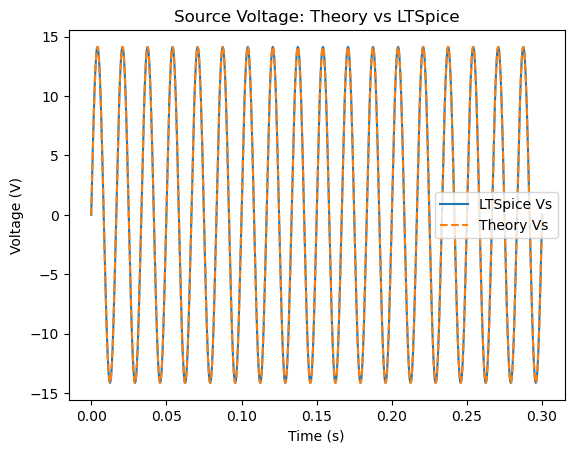

In [153]:
plt.plot(df["time"], df["vs_fixed"], label="LTSpice Vs")
plt.plot(df["time"], 10*np.sqrt(2)*np.sin(2*np.pi*60*df["time"]), '--', label="Theory Vs")

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Source Voltage: Theory vs LTSpice")
plt.show()

In [154]:
df.loc[df["vs"].idxmax()]

time                    0.012485
vs                     14.139770
vR                     -6.749799
vL                    -12.229170
vC                      4.839206
vSUM                   14.139763
abs_error               0.000007
percent_diff          199.999950
percent_diff_exact    199.999950
vs_fixed              -14.139770
error_option1          28.279533
error_option2           0.000007
vs_theory             -14.141901
Name: 83, dtype: float64

In [157]:
print("Vpeak =", Vpeak)
print("LTSpice source max =", np.max(df["vs_fixed"]))
print("LTSpice source min =", np.min(df["vs_fixed"]))

Vpeak = 14.142135623730951
LTSpice source max = 14.12703
LTSpice source min = -14.13977


In [35]:
df["vs_theory"] = vs_theory(df["time"])

print("Max source difference:", np.max(np.abs(df["vs_theory"] - df["vs_fixed"])))

Max source difference: 0.002140239714268688
